In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
print("Column Information:")
print(df.info())

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha              

In [ ]:
# Total number of entries (rows)
print("\nTotal number of entries:", len(df))


Total number of entries: 4000


In [ ]:
# Seasonal Performance Analysis

seasonal_summary = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

seasonal_summary

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Efficiency
Season,,,,,,,
Kharif,1779,5.64,46.31,710719.06,531804.41,178914.65,5.89
Rabi,1627,5.08,41.49,601526.05,513836.58,87689.47,5.19
Zaid,594,4.67,38.89,519171.90,543976.73,-24804.82,4.41


In [ ]:
seasonal_patterns = df.groupby("Season").agg(

    # Environmental patterns
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Temperature_C=("Avg_Temperature_C", "mean"),
    Avg_Humidity_pct=("Humidity_pct", "mean"),
    Avg_Sunlight_Hours=("Sunlight_Hours_Day", "mean"),
    Avg_Soil_Moisture_pct=("Soil_Moisture_pct", "mean"),

    # Resource and input patterns
    Avg_Nitrogen_kg_ha=("Nitrogen_kg_ha", "mean"),
    Avg_Phosphorus_kg_ha=("Phosphorus_kg_ha", "mean"),
    Avg_Potassium_kg_ha=("Potassium_kg_ha", "mean"),
    Avg_Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Avg_Pesticide_Litre_ha=("Pesticide_Litre_ha", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),

    # Agricultural and economic patterns
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),

    # Risk pattern
    Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

seasonal_patterns

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Humidity_pct,Avg_Sunlight_Hours,Avg_Soil_Moisture_pct,Avg_Nitrogen_kg_ha,Avg_Phosphorus_kg_ha,Avg_Potassium_kg_ha,Avg_Fertilizer_kg_ha,Avg_Pesticide_Litre_ha,Avg_Water_Used_m3,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Profit_INR,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20,120.02,58.10,105.30,187.08,5.08,6102.20,5.64,46.31,178914.65,5.89,54.47
Rabi,436.00,23.49,57.89,7.59,24.05,120.40,57.31,103.93,185.41,5.02,5846.99,5.08,41.49,87689.47,5.19,40.48
Zaid,299.42,31.04,52.01,8.18,19.17,120.53,58.13,105.42,184.64,5.17,6419.89,4.67,38.89,-24804.82,4.41,38.22


In [ ]:
pattern_summary = pd.DataFrame({
    "Highest_Season": seasonal_patterns.idxmax(),
    "Highest_Value": seasonal_patterns.max(),
    "Lowest_Season": seasonal_patterns.idxmin(),
    "Lowest_Value": seasonal_patterns.min()
})

pattern_summary

,Highest_Season,Highest_Value,Lowest_Season,Lowest_Value
Avg_Rainfall_mm,Kharif,852.08,Zaid,299.42
Avg_Temperature_C,Zaid,31.04,Rabi,23.49
Avg_Humidity_pct,Kharif,71.81,Zaid,52.01
Avg_Sunlight_Hours,Zaid,8.18,Kharif,6.79
Avg_Soil_Moisture_pct,Kharif,31.20,Zaid,19.17
Avg_Nitrogen_kg_ha,Zaid,120.53,Kharif,120.02
Avg_Phosphorus_kg_ha,Zaid,58.13,Rabi,57.31
Avg_Potassium_kg_ha,Zaid,105.42,Rabi,103.93
Avg_Fertilizer_kg_ha,Kharif,187.08,Zaid,184.64
Avg_Pesticide_Litre_ha,Zaid,5.17,Rabi,5.02


In [ ]:
import pandas as pd

# Numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Mean value of every numerical characteristic for each season
seasonal_characteristics = df.groupby("Season")[numeric_cols].mean().round(2)

seasonal_characteristics

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,7.94,852.08,28.45,71.81,6.79,6.73,31.20,120.02,58.10,105.30,...,0.82,5.64,46.31,44850.91,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,436.00,23.49,57.89,7.59,6.67,24.05,120.40,57.31,103.93,...,0.83,5.08,41.49,44747.97,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,299.42,31.04,52.01,8.18,6.69,19.17,120.53,58.13,105.42,...,0.82,4.67,38.89,44212.03,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


In [ ]:
seasonal_change = pd.DataFrame({
    "Minimum_Seasonal_Mean": seasonal_characteristics.min(),
    "Maximum_Seasonal_Mean": seasonal_characteristics.max(),
    "Absolute_Change": (
        seasonal_characteristics.max() -
        seasonal_characteristics.min()
    ),
    "Percentage_Change": (
        (seasonal_characteristics.max() -
         seasonal_characteristics.min())
        / seasonal_characteristics.min().abs()
        * 100
    )
}).round(2)

seasonal_change = seasonal_change.sort_values(
    "Percentage_Change",
    ascending=False
)

seasonal_change

,Minimum_Seasonal_Mean,Maximum_Seasonal_Mean,Absolute_Change,Percentage_Change
Profit_INR,-24804.82,178914.65,203719.47,821.29
Rainfall_mm,299.42,852.08,552.66,184.58
Soil_Moisture_pct,19.17,31.20,12.03,62.75
Disease_Pest_Risk_pct,38.22,54.47,16.25,42.52
Humidity_pct,52.01,71.81,19.80,38.07
Revenue_INR,519171.90,710719.06,191547.16,36.89
Water_Efficiency_t_per_1000m3,4.41,5.89,1.48,33.56
Avg_Temperature_C,23.49,31.04,7.55,32.14
Yield_Tonnes_Ha,4.67,5.64,0.97,20.77
Sunlight_Hours_Day,6.79,8.18,1.39,20.47


In [ ]:
seasonal_cv = (
    seasonal_characteristics.std(axis=0)
    / seasonal_characteristics.mean(axis=0).abs()
    * 100
).round(2)

seasonal_cv = seasonal_cv.sort_values(ascending=False)

seasonal_cv

,0
Profit_INR,126.61
Rainfall_mm,54.40
Soil_Moisture_pct,24.39
Disease_Pest_Risk_pct,19.83
Humidity_pct,16.79
Revenue_INR,15.74
Water_Efficiency_t_per_1000m3,14.34
Avg_Temperature_C,13.87
Yield_Tonnes_Ha,9.49
Sunlight_Hours_Day,9.28


In [ ]:

activity_cols = [
    "Farm_Area_Hectares",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Seed_Quality_Score"
]

seasonal_activities = df.groupby("Season")[activity_cols].mean().round(2)

print("Average agricultural activities and resource usage by season:")
print(seasonal_activities)


Average agricultural activities and resource usage by season:
        Farm_Area_Hectares  Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha  \
Season                                                                          
Kharif                7.94          120.02             58.10           105.30   
Rabi                  7.75          120.40             57.31           103.93   
Zaid                  8.09          120.53             58.13           105.42   

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  \
Season                                                        
Kharif            187.08                5.08        6102.20   
Rabi              185.41                5.02        5846.99   
Zaid              184.64                5.17        6419.89   

        Seed_Quality_Score  
Season                      
Kharif                0.82  
Rabi                  0.83  
Zaid                  0.82  


In [ ]:
crop_by_season = pd.crosstab(
    df["Season"],
    df["Crop"],
    normalize="index"
) * 100

print("Crop distribution (%) within each season:")
print(crop_by_season.round(2))

Crop distribution (%) within each season:
Crop    Chilli  Cotton  Groundnut  Maize  Pulses   Rice  Sugarcane  Wheat
Season                                                                   
Kharif   10.40   12.09      10.85  13.15   12.42  17.65       7.03  16.41
Rabi     10.02   12.35      10.88  14.32   13.09  16.84       7.93  14.57
Zaid     10.77   15.49       9.09  14.14   10.44  17.17       8.59  14.31


In [ ]:
irrigation_by_season = pd.crosstab(
    df["Season"],
    df["Irrigation_Method"],
    normalize="index"
) * 100

print("Irrigation method distribution (%) within each season:")
print(irrigation_by_season.round(2))

Irrigation method distribution (%) within each season:
Irrigation_Method   Drip  Flood  Rainfed  Sprinkler
Season                                             
Kharif             22.77  33.16    26.03      18.04
Rabi               22.74  32.33    26.92      18.01
Zaid               23.57  32.66    23.57      20.20


In [ ]:
df.groupby("Season")["Farm_Area_Hectares"].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
Season,,,,
Kharif,7.94,8.18,0.5,15.00
Rabi,7.75,7.68,0.5,15.00
Zaid,8.09,8.09,0.5,14.99


In [ ]:
resource_cols = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3"
]

resource_by_season = df.groupby("Season")[resource_cols].mean().round(2)

print("Average resource usage across seasons:")
print(resource_by_season)

Average resource usage across seasons:
        Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha  Fertilizer_kg_ha  \
Season                                                                        
Kharif          120.02             58.10           105.30            187.08   
Rabi            120.40             57.31           103.93            185.41   
Zaid            120.53             58.13           105.42            184.64   

        Pesticide_Litre_ha  Water_Used_m3  
Season                                     
Kharif                5.08        6102.20  
Rabi                  5.02        5846.99  
Zaid                  5.17        6419.89  


In [ ]:
resource_variation = pd.DataFrame({
    "Minimum": resource_by_season.min(),
    "Maximum": resource_by_season.max(),
    "Percentage_Variation": (
        (resource_by_season.max() - resource_by_season.min())
        / resource_by_season.min().abs()
        * 100
    )
}).round(2)

resource_variation = resource_variation.sort_values(
    "Percentage_Variation",
    ascending=False
)

print("Percentage variation in resource usage:")
print(resource_variation)

Percentage variation in resource usage:
                    Minimum  Maximum  Percentage_Variation
Water_Used_m3       5846.99  6419.89                  9.80
Pesticide_Litre_ha     5.02     5.17                  2.99
Potassium_kg_ha      103.93   105.42                  1.43
Phosphorus_kg_ha      57.31    58.13                  1.43
Fertilizer_kg_ha     184.64   187.08                  1.32
Nitrogen_kg_ha       120.02   120.53                  0.42


In [ ]:
environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

performance_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]

# Correlation between environmental conditions and performance
correlation_matrix = df[environmental_cols + performance_cols].corr()

environmental_performance_corr = correlation_matrix.loc[
    environmental_cols,
    performance_cols
].round(3)

print("Correlation between environmental conditions and agricultural performance:")
print(environmental_performance_corr)

Correlation between environmental conditions and agricultural performance:
                    Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  \
Rainfall_mm                   0.031              0.025        0.099   
Avg_Temperature_C             0.009              0.007        0.027   
Humidity_pct                  0.011              0.004        0.057   
Sunlight_Hours_Day           -0.015             -0.024       -0.047   
Soil_pH                      -0.021             -0.013       -0.009   
Soil_Moisture_pct             0.010              0.005        0.080   

                    Profit_INR  Water_Efficiency_t_per_1000m3  
Rainfall_mm              0.108                          0.058  
Avg_Temperature_C        0.009                          0.007  
Humidity_pct             0.064                          0.026  
Sunlight_Hours_Day      -0.055                         -0.021  
Soil_pH                 -0.013                         -0.010  
Soil_Moisture_pct        0.092             

In [ ]:
for season in df["Season"].unique():
    season_data = df[df["Season"] == season]

    corr = season_data[environmental_cols + performance_cols].corr().loc[
        environmental_cols,
        performance_cols
    ]

    print(f"\n--- {season} ---")
    print(corr.round(3))


--- Kharif ---
                    Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  \
Rainfall_mm                  -0.019             -0.019       -0.084   
Avg_Temperature_C            -0.011             -0.003       -0.008   
Humidity_pct                 -0.017             -0.020       -0.022   
Sunlight_Hours_Day           -0.021             -0.030        0.012   
Soil_pH                      -0.026             -0.022       -0.043   
Soil_Moisture_pct             0.001             -0.012        0.017   

                    Profit_INR  Water_Efficiency_t_per_1000m3  
Rainfall_mm             -0.101                         -0.027  
Avg_Temperature_C       -0.020                         -0.027  
Humidity_pct            -0.033                         -0.008  
Sunlight_Hours_Day       0.024                         -0.014  
Soil_pH                 -0.039                         -0.018  
Soil_Moisture_pct        0.022                         -0.005  

--- Rabi ---
                    Yiel

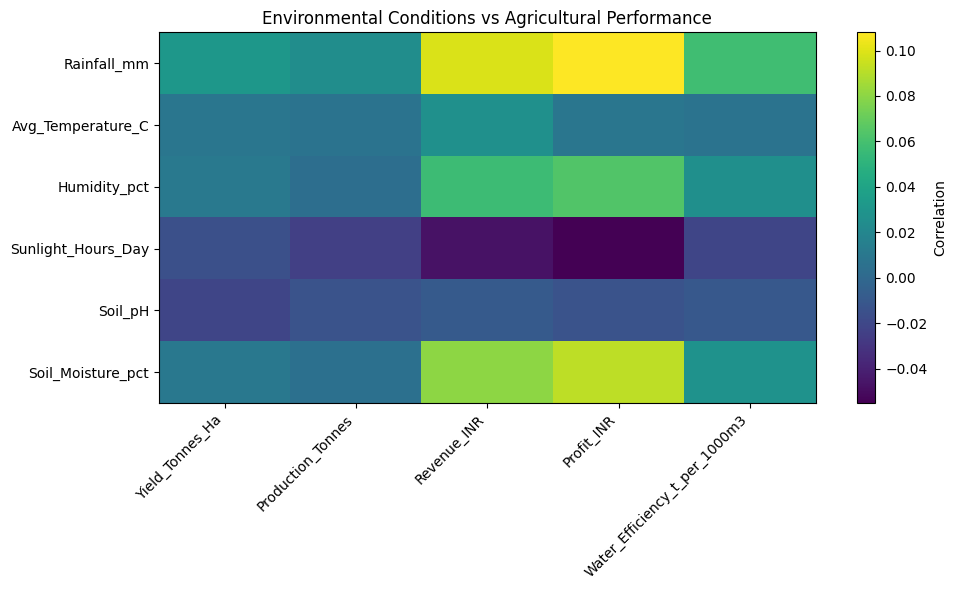

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.imshow(
    environmental_performance_corr,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(performance_cols)),
    performance_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(environmental_cols)),
    environmental_cols
)

plt.title("Environmental Conditions vs Agricultural Performance")
plt.tight_layout()
plt.show()


In [ ]:
economic_cols = [
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]

economic_by_season = df.groupby("Season")[economic_cols].agg(
    ["mean", "median"]
).round(2)

print("Economic outcomes across seasons:")
print(economic_by_season)

Economic outcomes across seasons:
       Market_Price_INR_Tonne          Total_Cost_INR           Revenue_INR  \
                         mean   median           mean    median        mean   
Season                                                                        
Kharif               44850.91  25793.0      531804.41  524840.0   710719.06   
Rabi                 44747.97  26041.0      513836.58  506733.0   601526.05   
Zaid                 44212.03  25749.5      543976.73  534833.0   519171.90   

                 Profit_INR           
          median       mean   median  
Season                                
Kharif  520196.0  178914.65  38808.0  
Rabi    438156.0   87689.47  -3187.0  
Zaid    373700.5  -24804.82 -62144.0  


In [ ]:
df["Profit_Margin_pct"] = (
    df["Profit_INR"] / df["Revenue_INR"] * 100
)

profit_margin_by_season = df.groupby("Season")[
    "Profit_Margin_pct"
].agg(["mean", "median"]).round(2)

print("Profit margin across seasons:")
print(profit_margin_by_season)

Profit margin across seasons:
         mean  median
Season               
Kharif -38.64   11.09
Rabi   -44.27   -1.34
Zaid   -69.35  -24.59


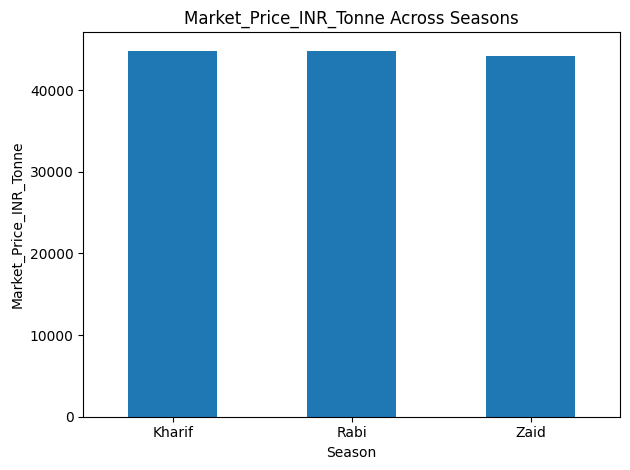

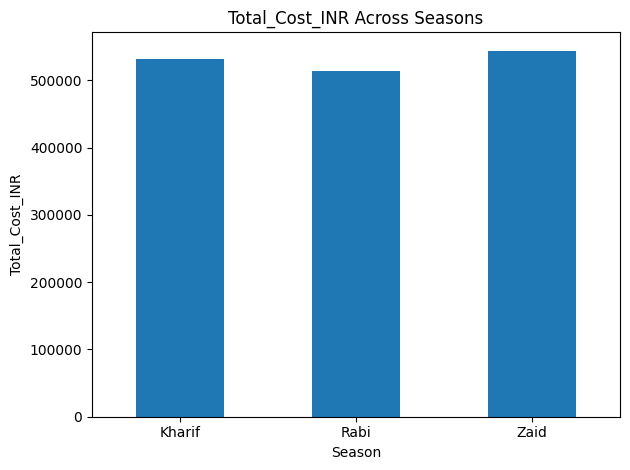

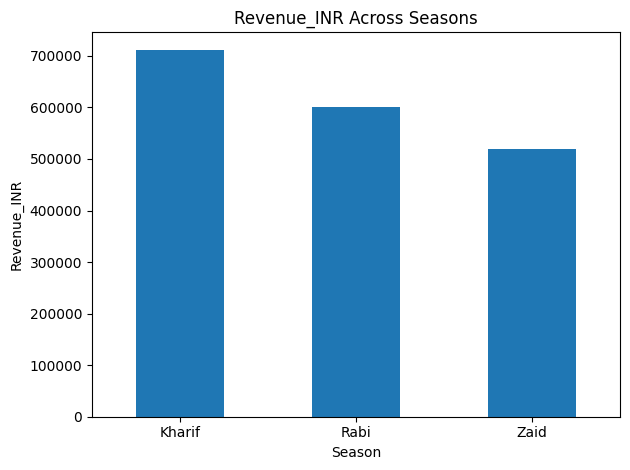

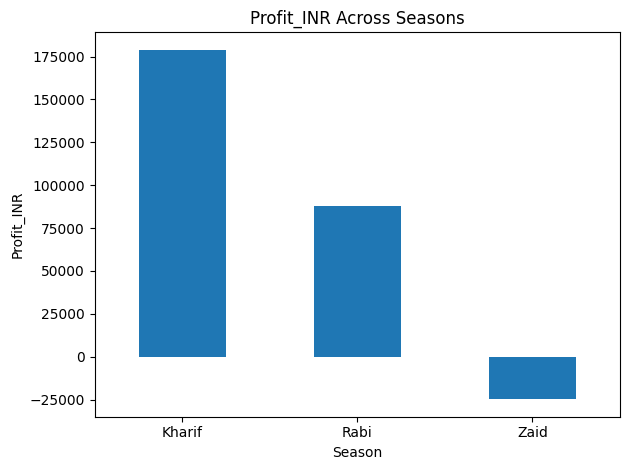

In [ ]:
import matplotlib.pyplot as plt

economic_means = df.groupby("Season")[[
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]].mean()

for column in economic_means.columns:
    economic_means[column].plot(kind="bar")

    plt.title(f"{column} Across Seasons")
    plt.xlabel("Season")
    plt.ylabel(column)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

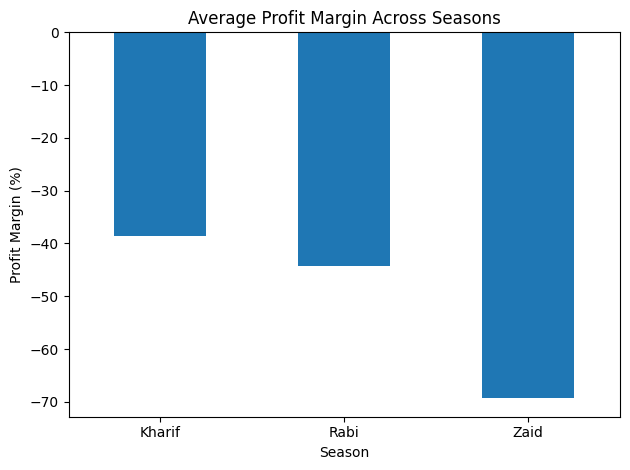

In [ ]:
df.groupby("Season")["Profit_Margin_pct"].mean().plot(kind="bar")

plt.title("Average Profit Margin Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
seasonal_economic = df.groupby("Season").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
)

seasonal_economic["Profit_Margin_pct"] = (
    seasonal_economic["Average_Profit"]
    / seasonal_economic["Average_Revenue"]
    * 100
).round(2)

seasonal_economic

,Average_Revenue,Average_Cost,Average_Profit,Profit_Margin_pct
Season,,,,
Kharif,710719.055649,531804.408094,178914.647555,25.17
Rabi,601526.048556,513836.578365,87689.470191,14.58
Zaid,519171.904040,543976.728956,-24804.824916,-4.78


In [ ]:
state_season = df.groupby(["State", "Season"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean")
).round(2)

print("Seasonal performance across States:")
print(state_season)

Seasonal performance across States:
                       Avg_Yield  Avg_Profit  Avg_Revenue  Avg_Water_Used
State          Season                                                    
Andhra Pradesh Kharif       5.69   169315.52    691980.02         6598.72
               Rabi         3.49    26315.71    544197.86         4872.34
               Zaid         4.48   -84084.87    515688.32         7379.21
Gujarat        Kharif       6.34   217051.33    749657.17         6227.48
               Rabi         5.52    82846.20    615179.88         6018.77
               Zaid         4.10  -106929.61    459401.58         6231.52
Karnataka      Kharif       6.52   201226.21    765923.74         6980.67
               Rabi         4.61    70952.61    577493.39         5709.81
               Zaid         6.62    23310.91    547077.08         6776.00
Madhya Pradesh Kharif       6.00   134242.40    640088.36         5391.38
               Rabi         3.80    61576.26    584038.23         5894.84
  

In [ ]:
state_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).round(2)

print(state_profit)

Season             Kharif       Rabi       Zaid
State                                          
Andhra Pradesh  169315.52   26315.71  -84084.87
Gujarat         217051.33   82846.20 -106929.61
Karnataka       201226.21   70952.61   23310.91
Madhya Pradesh  134242.40   61576.26     209.70
Maharashtra     168801.05  159581.50  -40597.60
Punjab          133779.10  169294.52   62109.69
Tamil Nadu      211303.96   70456.86  -15175.20
Telangana       199668.38   62824.60  -34620.78


In [ ]:
state_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).round(2)

print(state_profit)

Season             Kharif       Rabi       Zaid
State                                          
Andhra Pradesh  169315.52   26315.71  -84084.87
Gujarat         217051.33   82846.20 -106929.61
Karnataka       201226.21   70952.61   23310.91
Madhya Pradesh  134242.40   61576.26     209.70
Maharashtra     168801.05  159581.50  -40597.60
Punjab          133779.10  169294.52   62109.69
Tamil Nadu      211303.96   70456.86  -15175.20
Telangana       199668.38   62824.60  -34620.78


In [ ]:
crop_profit = df.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).round(2)

print(crop_profit)

Season         Kharif       Rabi       Zaid
Crop                                       
Chilli      954380.42  638572.50  448659.09
Cotton      216999.55  107343.59  -53925.34
Groundnut   108265.44   10416.54  -68872.50
Maize       -39332.67  -89133.40 -194049.17
Pulses       43338.90  -14309.14 -139227.81
Rice        -64903.40  -98427.87 -227239.34
Sugarcane  1000790.81  731612.86  583635.80
Wheat      -105871.87 -119954.57 -193208.95


In [ ]:
# Q9: Identify unusual or unexpected seasonal patterns

# 1. Seasonal averages for key performance variables
season_summary = df.groupby('Season')[
    ['Yield_Tonnes_Ha',
     'Production_Tonnes',
     'Revenue_INR',
     'Profit_INR',
     'Water_Used_m3',
     'Water_Efficiency_t_per_1000m3']
].mean()

print("Seasonal Performance Summary:")
display(season_summary.round(2))


# 2. Identify crops whose seasonal profit pattern differs from
# the general pattern Kharif > Rabi > Zaid
crop_profit = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().unstack()

print("\nCrop-wise Seasonal Profit:")
display(crop_profit.round(2))


# 3. Identify states whose best-profit season is NOT Kharif
state_profit = df.groupby(['State', 'Season'])['Profit_INR'].mean().unstack()

best_season_state = state_profit.idxmax(axis=1)

print("\nMost Profitable Season by State:")
display(best_season_state.to_frame('Best_Season'))


# 4. Identify states where Zaid is more profitable than Rabi
print("\nStates where Zaid Profit > Rabi Profit:")
zaid_better_than_rabi = state_profit[
    state_profit['Zaid'] > state_profit['Rabi']
]

display(zaid_better_than_rabi[['Rabi', 'Zaid']].round(2))


# 5. Identify crops where Zaid is more profitable than Rabi
print("\nCrops where Zaid Profit > Rabi Profit:")
zaid_crop = crop_profit[
    crop_profit['Zaid'] > crop_profit['Rabi']
]

display(zaid_crop[['Rabi', 'Zaid']].round(2))

Seasonal Performance Summary:


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.64,46.31,710719.06,178914.65,6102.20,5.89
Rabi,5.08,41.49,601526.05,87689.47,5846.99,5.19
Zaid,4.67,38.89,519171.90,-24804.82,6419.89,4.41



Crop-wise Seasonal Profit:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95



Most Profitable Season by State:


,Best_Season
State,
Andhra Pradesh,Kharif
Gujarat,Kharif
Karnataka,Kharif
Madhya Pradesh,Kharif
Maharashtra,Kharif
Punjab,Rabi
Tamil Nadu,Kharif
Telangana,Kharif



States where Zaid Profit > Rabi Profit:


Season,Rabi,Zaid
State,,



Crops where Zaid Profit > Rabi Profit:


Season,Rabi,Zaid
Crop,,
